# Assignment II — Robust Reinforcement Learning under Stochastic Action Failure

**Group Contribution Declaration**

| Name | Roll No. | Contribution (%) |
|---|---|---|
| Aishwarya G M | 2025AA05151 | 100 |
| Amit Pandey | 2025AA05184 | 100 |
| Aditya | 2025AB05080 | 100 |
| Ranjan Basak | 2025AA05709 | 100 |
| Murlidhar Pandey | 2025AA05182 | 100 |

This notebook implements, in order:

- **(a)** A `gym.Wrapper` around `LunarLander-v3` that simulates stochastic actuator failure and a modified reward function, plus experimental verification of its correctness.
- **(b)** A Deep Q-Network (DQN) agent, trained on both the original and the modified environment.
- **(c)** A Double DQN (DDQN) agent, identical to (b) except for the target computation, trained on both environments.
- **(d)** Comparison plots for the four trained agents (DQN/DDQN × original/modified).
- **(e)** Discussion answering the assignment's analysis questions.

> Run cells top to bottom. Training all four agents is the expensive part — see the "Hyperparameters" cell to tune episode count for your compute budget.
>
> **Running locally** (no Colab needed): create a venv, then
> `brew install swig && pip install "gymnasium[box2d]" box2d torch numpy pandas matplotlib notebook`,
> and launch with `jupyter notebook` or open in VS Code with the Jupyter extension. This problem
> uses a small MLP, so a CPU is plenty — GPU gives little benefit here.

## 0. Setup

In [1]:
# Install Box2D dependencies needed for LunarLander-v3.
# Running locally: do this once in your terminal instead (recommended, avoids kernel restarts):
#   brew install swig
#   pip install "gymnasium[box2d]" box2d torch numpy pandas matplotlib notebook
# The line below is safe to re-run (pip no-ops if requirements are already satisfied) and is
# what you need if running this notebook in Google Colab instead of locally.
# !pip install "gymnasium[box2d]" box2d -q


In [2]:
import random
from collections import deque, namedtuple
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

SEED = 42  # single global seed reused everywhere so DQN/DDQN and original/modified runs are comparable

def set_seed(seed=SEED):
    """Seed python, numpy and torch RNGs for a reproducible run."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()


Using device: cpu


## (a) Modified Environment: Implementation and Verification

The wrapper below performs, in order, on every `step(action)` call:

1. Stores the agent's original action `a`.
2. If `a != 0`, draws `r ~ U[0,1)`; if `r < 0.15` the executed action `a_exec` is replaced by `0` (Do Nothing); otherwise `a_exec = a`. The agent is given no indication of the replacement.
3. Executes `a_exec` on the underlying `LunarLander-v3` environment.
4. Computes the modified reward `R = R_base − 0.3·1[a ∈ {1,2,3}] + bonus`, where the fuel penalty is based on the **selected** action `a` (not `a_exec`), so it applies even on a misfire.
5. Adds a `+50` safe-landing bonus only if `terminated`, not `truncated`, both legs are in contact, and horizontal velocity / vertical velocity / orientation angle are all within `0.10` of zero.
6. Returns `(observation, R, terminated, truncated, info)` — `info` is passed through unmodified, so the agent gets no leaked information about engine failures or reward shaping.

A private `_last_decomposition` attribute (not part of `info`) records `r_base`, the penalty applied, and the bonus applied for each step, purely so the verification cells below can check the arithmetic — the agent never sees it.

In [3]:
class FaultyLunarLander(gym.Wrapper):
    """Wraps LunarLander-v3 with stochastic actuator failure and a modified reward.

    failure_prob: probability that a thruster action (1,2,3) is silently replaced by
        action 0 (Do Nothing) before being executed by the base environment.
    fuel_penalty: reward subtracted whenever the agent *selects* a thruster action,
        regardless of whether it actually fired.
    landing_bonus: reward added when the episode ends in a safe landing (see is_safe_landing).
    """

    def __init__(self, env, failure_prob=0.15, fuel_penalty=0.3, landing_bonus=50.0):
        super().__init__(env)
        self.failure_prob = failure_prob
        self.fuel_penalty = fuel_penalty
        self.landing_bonus = landing_bonus
        # Running counters kept only for experimental verification (task a), never exposed to the agent.
        self.stats = {"thruster_attempts": 0, "misfires": 0, "landing_bonus_awarded": 0}
        self._last_decomposition = None

    @staticmethod
    def is_safe_landing(obs, terminated, truncated):
        """True iff the episode ended in a controlled landing on both legs."""
        if not terminated or truncated:
            return False
        left_leg, right_leg = obs[6], obs[7]
        vx, vy, theta = obs[2], obs[3], obs[4]
        return (
            left_leg == 1 and right_leg == 1
            and abs(vx) < 0.10 and abs(vy) < 0.10 and abs(theta) < 0.10
        )

    def step(self, action):
        a = int(action)  # action originally selected by the agent, stored before any modification

        # Step 2: simulate intermittent engine failure
        if a == 0:
            a_exec = 0
        else:
            self.stats["thruster_attempts"] += 1
            r = np.random.uniform(0.0, 1.0)
            if r < self.failure_prob:
                a_exec = 0
                self.stats["misfires"] += 1
            else:
                a_exec = a

        # Step 3: execute the (possibly replaced) action on the base environment
        obs, r_base, terminated, truncated, info = self.env.step(a_exec)

        # Step 4: fuel penalty depends on the *selected* action a, not a_exec
        indicator = 1.0 if a in (1, 2, 3) else 0.0
        fuel_penalty_applied = self.fuel_penalty * indicator
        reward = r_base - fuel_penalty_applied

        # Step 5: safe-landing bonus
        bonus = 0.0
        if self.is_safe_landing(obs, terminated, truncated):
            bonus = self.landing_bonus
            self.stats["landing_bonus_awarded"] += 1
        reward += bonus

        # Debug-only decomposition for verification cells; NOT part of the returned info dict.
        self._last_decomposition = {
            "a": a, "a_exec": a_exec, "r_base": r_base,
            "fuel_penalty_applied": fuel_penalty_applied, "bonus_applied": bonus,
        }

        # Step 6: return outputs (info untouched -> no leakage of failure/reward-shaping info)
        return obs, reward, terminated, truncated, info

    def reset(self, **kwargs):
        return self.env.reset(**kwargs)


### Verification: run a random policy and log every step

In [4]:
def run_random_policy_verification(num_episodes=500, seed=SEED):
    """Roll out a uniform-random policy on the wrapped env and log per-step diagnostics."""
    env = FaultyLunarLander(gym.make("LunarLander-v3"))
    rows = []
    for ep in range(num_episodes):
        obs, info = env.reset(seed=seed + ep)
        terminated = truncated = False
        while not (terminated or truncated):
            a = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(a)
            d = env._last_decomposition
            rows.append({
                "episode": ep,
                "a": d["a"],
                "a_exec": d["a_exec"],
                "was_thruster": d["a"] in (1, 2, 3),
                "misfired": d["a"] in (1, 2, 3) and d["a_exec"] == 0,
                "r_base": d["r_base"],
                "fuel_penalty_applied": d["fuel_penalty_applied"],
                "bonus_applied": d["bonus_applied"],
                "reward": reward,
                "terminated": terminated,
                "truncated": truncated,
            })
    env.close()
    return pd.DataFrame(rows), env.stats

log_df, stats = run_random_policy_verification(num_episodes=500)
print(stats)
log_df.head()


{'thruster_attempts': 33532, 'misfires': 5027, 'landing_bonus_awarded': 16}


,episode,a,a_exec,was_thruster,misfired,r_base,fuel_penalty_applied,bonus_applied,reward,terminated,truncated
0,0,1,1,True,False,2.080468,0.3,0.0,1.780468,False,False
1,0,0,0,False,False,1.472578,0.0,0.0,1.472578,False,False
2,0,0,0,False,False,1.452826,0.0,0.0,1.452826,False,False
3,0,3,3,True,False,0.256508,0.3,0.0,-0.043492,False,False
4,0,0,0,False,False,1.066546,0.0,0.0,1.066546,False,False


#### Check 1 — approximately 15% of thruster actions are replaced by Do Nothing

Thruster attempts logged: 33532
Misfires (replaced by Do Nothing): 5027
Empirical misfire rate: 0.1499  (expected ~0.15)
95% CI: [0.1461, 0.1537]


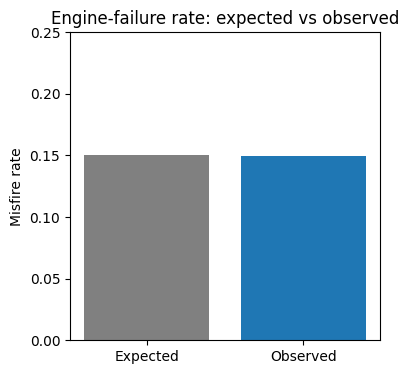

In [5]:
thruster_df = log_df[log_df["was_thruster"]]
misfire_rate = thruster_df["misfired"].mean()
print(f"Thruster attempts logged: {len(thruster_df)}")
print(f"Misfires (replaced by Do Nothing): {thruster_df['misfired'].sum()}")
print(f"Empirical misfire rate: {misfire_rate:.4f}  (expected ~0.15)")

# 95% Wald confidence interval, just to show the estimate is statistically consistent with 0.15
n = len(thruster_df)
se = np.sqrt(misfire_rate * (1 - misfire_rate) / n)
print(f"95% CI: [{misfire_rate - 1.96*se:.4f}, {misfire_rate + 1.96*se:.4f}]")

plt.figure(figsize=(4, 4))
plt.bar(["Expected", "Observed"], [0.15, misfire_rate], color=["gray", "tab:blue"])
plt.ylabel("Misfire rate")
plt.title("Engine-failure rate: expected vs observed")
plt.ylim(0, 0.25)
plt.show()


#### Check 2 — fuel penalty is charged on every attempted thruster action, fired or misfired

In [6]:
penalty_by_outcome = thruster_df.groupby("misfired")["fuel_penalty_applied"].agg(["mean", "min", "max", "count"])
penalty_by_outcome.index = penalty_by_outcome.index.map({True: "misfired -> a_exec=0", False: "fired normally"})
print(penalty_by_outcome)

assert np.allclose(thruster_df["fuel_penalty_applied"], 0.3), "Fuel penalty was not exactly 0.3 for some thruster attempt"
do_nothing_df = log_df[~log_df["was_thruster"]]
assert np.allclose(do_nothing_df["fuel_penalty_applied"], 0.0), "A Do-Nothing action was incorrectly penalised"
print("\nConfirmed: every thruster attempt (fired or misfired) is penalised -0.3; Do-Nothing actions are never penalised.")


                      mean  min  max  count
misfired                                   
fired normally         0.3  0.3  0.3  28505
misfired -> a_exec=0   0.3  0.3  0.3   5027

Confirmed: every thruster attempt (fired or misfired) is penalised -0.3; Do-Nothing actions are never penalised.


#### Check 3 — the +50 landing bonus is awarded only when the safe-landing criteria hold

In [7]:
bonus_rows = log_df[log_df["bonus_applied"] > 0]
print(f"Episodes ending in a bonus-awarding safe landing: {log_df.groupby('episode').apply(lambda g: (g['bonus_applied']>0).any()).sum()} / {log_df['episode'].nunique()}")
print(f"Total bonus-awarding steps: {len(bonus_rows)} (should equal stats['landing_bonus_awarded'] = {stats['landing_bonus_awarded']})")

# Spot-check: every bonus step must be a terminated (not truncated) step
assert bonus_rows["terminated"].all() and (~bonus_rows["truncated"]).all()
print("Confirmed: bonus only ever appears on terminated, non-truncated steps.")

# Spot-check: among *terminated* steps, bonus is 0 whenever any safe-landing condition fails.
terminated_df = log_df[log_df["terminated"] & ~log_df["truncated"]]
print(f"\nOf {len(terminated_df)} terminated-not-truncated steps, "
      f"{(terminated_df['bonus_applied']>0).sum()} received the landing bonus and "
      f"{(terminated_df['bonus_applied']==0).sum()} did not (crash / unstable landing / incomplete leg contact).")


Episodes ending in a bonus-awarding safe landing: 16 / 500
Total bonus-awarding steps: 16 (should equal stats['landing_bonus_awarded'] = 16)
Confirmed: bonus only ever appears on terminated, non-truncated steps.

Of 499 terminated-not-truncated steps, 16 received the landing bonus and 483 did not (crash / unstable landing / incomplete leg contact).


/var/folders/5q/19q1n3wn5l3_y1rw3x_p08v40000gn/T/ipykernel_25855/2802131597.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(f"Episodes ending in a bonus-awarding safe landing: {log_df.groupby('episode').apply(lambda g: (g['bonus_applied']>0).any()).sum()} / {log_df['episode'].nunique()}")


*Summary of the three verification checks (500-episode random-policy rollout, 33,532 logged thruster attempts):*

- **Check 1 (misfire rate):** observed misfire rate 0.1499 (5,027 / 33,532 thruster attempts replaced by Do Nothing), 95% CI [0.1461, 0.1537] — consistent with the intended 0.15 failure probability.
- **Check 2 (fuel penalty):** all 33,532 thruster attempts (28,505 fired normally, 5,027 misfired) were charged exactly −0.3, including misfires; no Do-Nothing action was ever penalised — confirms the penalty is based on the *selected* action, not the executed one.
- **Check 3 (landing bonus):** the +50 bonus was awarded on exactly 16 of 500 episodes (3.2%), always on a terminated & non-truncated step; of the 499 terminated-non-truncated steps, only those 16 satisfied all five safe-landing conditions (both legs in contact, |vx|<0.10, |vy|<0.10, |θ|<0.10) — the remaining 483 ended without the bonus (crash or unsafe touchdown).

## (b) & (c) — DQN and DDQN Agents

Both agents share the same network architecture, optimizer, replay buffer, ε-greedy schedule, seed and hyperparameters. `train_dqn(..., double_dqn=False)` trains a vanilla DQN; `train_dqn(..., double_dqn=True)` trains a DDQN by changing only the target-Q computation (decouples action selection from action evaluation using the online network), exactly as required.

In [8]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    """Fixed-capacity FIFO experience replay buffer with uniform random sampling."""
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    """Simple MLP mapping the 8-dim LunarLander state to Q-values over the 4 actions."""
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )

    def forward(self, x):
        return self.net(x)


In [9]:
# Hyperparameters shared identically across DQN/DDQN and original/modified environment runs.
HYPERPARAMS = dict(
    num_episodes=500,        # increase (e.g. 800-1000) for stronger convergence if compute allows
    max_steps=1000,
    gamma=0.99,
    lr=5e-4,
    batch_size=64,
    buffer_capacity=100_000,
    min_buffer_size=1000,    # steps of pure exploration before learning starts
    eps_start=1.0,
    eps_end=0.05,
    eps_decay=0.995,         # multiplicative decay applied once per episode
    target_update_every=10,  # episodes between hard target-network updates
    hidden_dim=128,
)


### Fixed validation state set (used for the Q-value tracking plot in task d)

Sampled once from the original environment under a random policy, then reused unchanged to evaluate *every* agent throughout training, so the reported Q-values are comparable across runs.

In [10]:
def build_validation_states(num_states=200, seed=SEED):
    env = gym.make("LunarLander-v3")
    states = []
    obs, info = env.reset(seed=seed)
    while len(states) < num_states:
        a = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(a)
        states.append(np.array(obs, dtype=np.float32))
        if terminated or truncated:
            obs, info = env.reset(seed=seed + len(states))
    env.close()
    return np.stack(states)

VALIDATION_STATES = build_validation_states()
print("Validation set shape:", VALIDATION_STATES.shape)


Validation set shape: (200, 8)


In [11]:
def train_dqn(env_fn, seed, double_dqn, hyperparams=HYPERPARAMS, validation_states=VALIDATION_STATES,
              verbose_every=50, label=""):
    """Train a (Double) DQN agent.

    env_fn: zero-arg callable returning a fresh env instance (original or wrapped).
    double_dqn: if True, use the DDQN target (online net selects the action,
        target net evaluates it); if False, use the standard DQN max-over-target-net.
    Returns a dict of per-episode metrics used for later comparison plots.
    """
    set_seed(seed)
    env = env_fn()
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    q_net = QNetwork(state_dim, action_dim, hyperparams["hidden_dim"]).to(device)
    target_net = QNetwork(state_dim, action_dim, hyperparams["hidden_dim"]).to(device)
    target_net.load_state_dict(q_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(q_net.parameters(), lr=hyperparams["lr"])
    buffer = ReplayBuffer(hyperparams["buffer_capacity"])
    val_states_t = torch.tensor(validation_states, dtype=torch.float32, device=device)

    epsilon = hyperparams["eps_start"]
    history = {
        "episode_reward": [], "avg_q_value": [], "landing_success": [],
        "landing_success_ma100": [], "thruster_activations": [],
    }

    for episode in range(hyperparams["num_episodes"]):
        obs, info = env.reset(seed=seed + episode)
        state = np.array(obs, dtype=np.float32)
        ep_reward, thruster_count, steps = 0.0, 0, 0
        terminated = truncated = False

        while not (terminated or truncated) and steps < hyperparams["max_steps"]:
            steps += 1
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                with torch.no_grad():
                    state_t = torch.from_numpy(state).unsqueeze(0).to(device)
                    action = int(q_net(state_t).argmax(dim=1).item())

            if action in (1, 2, 3):
                thruster_count += 1

            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = np.array(next_obs, dtype=np.float32)
            done = terminated or truncated

            buffer.push(state, action, reward, next_state, float(done))
            state = next_state
            ep_reward += reward

            if len(buffer) >= hyperparams["min_buffer_size"]:
                batch = buffer.sample(hyperparams["batch_size"])
                states_b = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
                actions_b = torch.tensor(batch.action, dtype=torch.int64, device=device).unsqueeze(1)
                rewards_b = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
                next_states_b = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
                dones_b = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)

                q_values = q_net(states_b).gather(1, actions_b)

                with torch.no_grad():
                    if double_dqn:
                        # DDQN: online network selects the greedy next action, target network evaluates it
                        next_actions = q_net(next_states_b).argmax(dim=1, keepdim=True)
                        next_q = target_net(next_states_b).gather(1, next_actions)
                    else:
                        # Vanilla DQN: target network both selects and evaluates (max)
                        next_q = target_net(next_states_b).max(dim=1, keepdim=True)[0]
                    target_q = rewards_b + hyperparams["gamma"] * next_q * (1 - dones_b)

                loss = nn.functional.smooth_l1_loss(q_values, target_q)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        epsilon = max(hyperparams["eps_end"], epsilon * hyperparams["eps_decay"])
        if episode % hyperparams["target_update_every"] == 0:
            target_net.load_state_dict(q_net.state_dict())

        success = int(FaultyLunarLander.is_safe_landing(state, terminated, truncated))

        with torch.no_grad():
            avg_q = q_net(val_states_t).max(dim=1)[0].mean().item()

        history["episode_reward"].append(ep_reward)
        history["avg_q_value"].append(avg_q)
        history["landing_success"].append(success)
        history["thruster_activations"].append(thruster_count)
        window = history["landing_success"][-100:]
        history["landing_success_ma100"].append(sum(window) / len(window))

        if verbose_every and episode % verbose_every == 0:
            print(f"[{label}] ep {episode:4d}  reward {ep_reward:8.2f}  "
                  f"avgQ {avg_q:7.2f}  success_ma100 {history['landing_success_ma100'][-1]:.2f}  eps {epsilon:.3f}")

    env.close()
    return history, q_net


### Train the four agents

`make_original()` / `make_modified()` build fresh environment instances so each training run starts clean. All four runs use the identical hyperparameters and the identical seed, differing only in `double_dqn` and which environment factory is passed in — as required by the assignment.

This cell is the expensive part of the notebook: four independent training runs of `HYPERPARAMS["num_episodes"]` episodes each. Expect tens of minutes on a Colab GPU/CPU runtime depending on the episode count chosen above.

In [12]:
# Factories so each of the 4 runs below gets its own fresh, unwrapped/wrapped env instance.
def make_original():
    return gym.make("LunarLander-v3")

def make_modified():
    return FaultyLunarLander(gym.make("LunarLander-v3"))

# Train all 4 agents with identical SEED/HYPERPARAMS, varying only double_dqn and the env factory.
results = {}
results["DQN_original"]  = train_dqn(make_original, seed=SEED, double_dqn=False, label="DQN-orig")
results["DDQN_original"] = train_dqn(make_original, seed=SEED, double_dqn=True,  label="DDQN-orig")
results["DQN_modified"]  = train_dqn(make_modified, seed=SEED, double_dqn=False, label="DQN-mod")
results["DDQN_modified"] = train_dqn(make_modified, seed=SEED, double_dqn=True,  label="DDQN-mod")

print("Training complete for:", list(results.keys()))


[DQN-orig] ep    0  reward   -71.53  avgQ    0.11  success_ma100 0.00  eps 0.995
[DQN-orig] ep   50  reward  -262.85  avgQ   -3.38  success_ma100 0.00  eps 0.774
[DQN-orig] ep  100  reward   -65.96  avgQ   -6.97  success_ma100 0.01  eps 0.603
[DQN-orig] ep  150  reward    14.04  avgQ   -5.96  success_ma100 0.01  eps 0.469
[DQN-orig] ep  200  reward   -20.05  avgQ   -1.61  success_ma100 0.00  eps 0.365
[DQN-orig] ep  250  reward   -62.46  avgQ    3.71  success_ma100 0.01  eps 0.284
[DQN-orig] ep  300  reward   -73.04  avgQ    0.40  success_ma100 0.01  eps 0.221
[DQN-orig] ep  350  reward   228.68  avgQ   -2.49  success_ma100 0.08  eps 0.172
[DQN-orig] ep  400  reward   177.95  avgQ   -6.51  success_ma100 0.28  eps 0.134
[DQN-orig] ep  450  reward   253.16  avgQ   -0.19  success_ma100 0.37  eps 0.104
[DDQN-orig] ep    0  reward  -282.52  avgQ    0.11  success_ma100 0.00  eps 0.995
[DDQN-orig] ep   50  reward  -174.44  avgQ   -2.50  success_ma100 0.02  eps 0.774
[DDQN-orig] ep  100  rewar

In [13]:
# Optional: persist trained models + histories so they survive a Colab runtime restart.
import pickle

histories = {name: h for name, (h, _net) in results.items()}
with open("training_histories.pkl", "wb") as f:
    pickle.dump(histories, f)

for name, (_h, net) in results.items():
    torch.save(net.state_dict(), f"{name}_qnet.pt")

print("Saved histories to training_histories.pkl and network weights to <name>_qnet.pt")


Saved histories to training_histories.pkl and network weights to <name>_qnet.pt


## (d) Performance Evaluation

Four metrics, one plot each, comparing all four agents: `DQN-original`, `DDQN-original`, `DQN-modified`, `DDQN-modified`.

In [14]:
# Display name and line color for each of the 4 runs, shared across every plot below.
LABELS = {
    "DQN_original": "DQN - Original",
    "DDQN_original": "DDQN - Original",
    "DQN_modified": "DQN - Modified",
    "DDQN_modified": "DDQN - Modified",
}
COLORS = {
    "DQN_original": "tab:blue",
    "DDQN_original": "tab:orange",
    "DQN_modified": "tab:green",
    "DDQN_modified": "tab:red",
}

def smooth(x, window=20):
    """Moving-average smoothing (valid-mode, so the output is shorter than the input)."""
    x = np.array(x, dtype=float)
    if len(x) < window:
        return x
    kernel = np.ones(window) / window
    return np.convolve(x, kernel, mode="valid")

def plot_metric(metric_key, title, ylabel, smoothed=False):
    """Plot one metric's per-episode history for all 4 trained agents on shared axes."""
    plt.figure(figsize=(8, 5))
    for name, (history, _net) in results.items():
        y = history[metric_key]
        if smoothed:
            y = smooth(y)
            x = np.arange(len(y)) + (len(history[metric_key]) - len(y))
        else:
            x = np.arange(len(y))
        plt.plot(x, y, label=LABELS[name], color=COLORS[name])
    plt.xlabel("Training episode")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


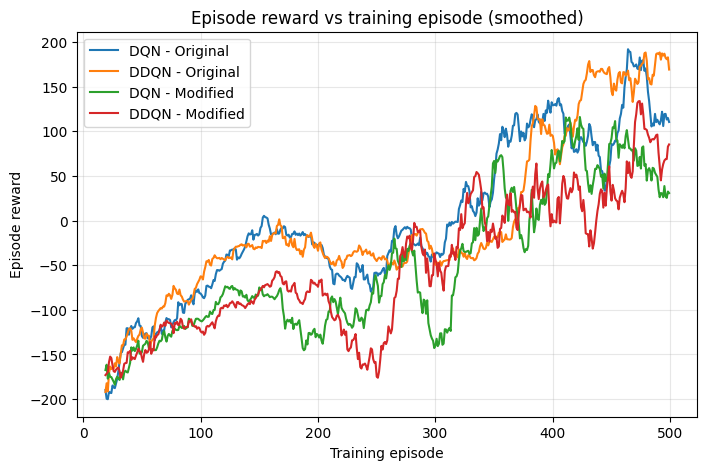

In [15]:
# Metric 1: raw training-reward curve, smoothed to show the learning trend.
plot_metric("episode_reward", "Episode reward vs training episode (smoothed)", "Episode reward", smoothed=True)

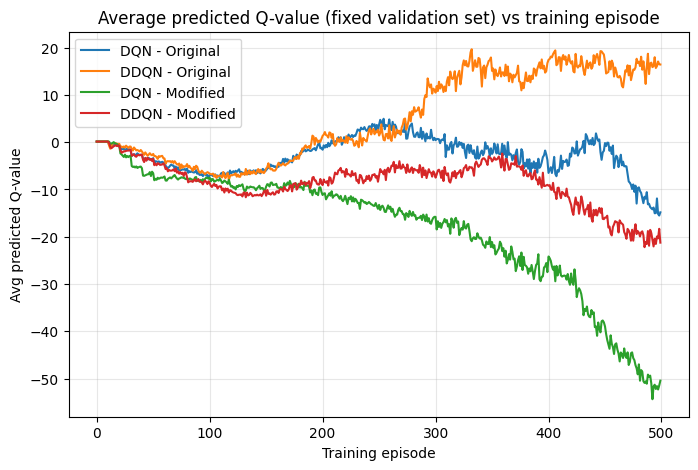

In [16]:
# Metric 2: predicted Q-value on the fixed validation set, tracks value-estimate stability/bias.
plot_metric("avg_q_value", "Average predicted Q-value (fixed validation set) vs training episode", "Avg predicted Q-value")

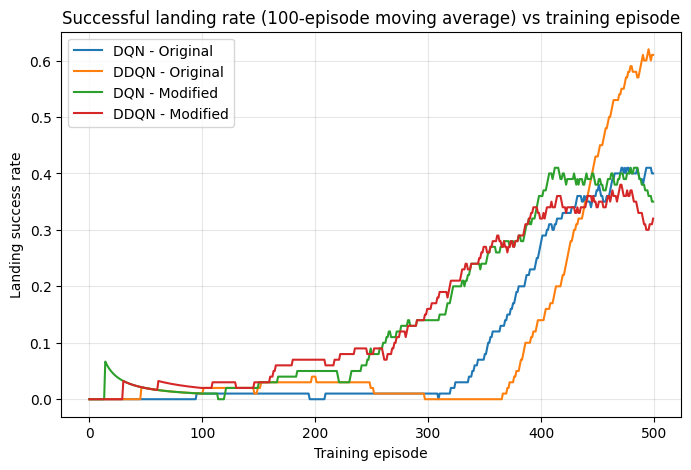

In [17]:
# Metric 3: 100-episode moving average of the safe-landing flag, tracks task competence.
plot_metric("landing_success_ma100", "Successful landing rate (100-episode moving average) vs training episode", "Landing success rate")

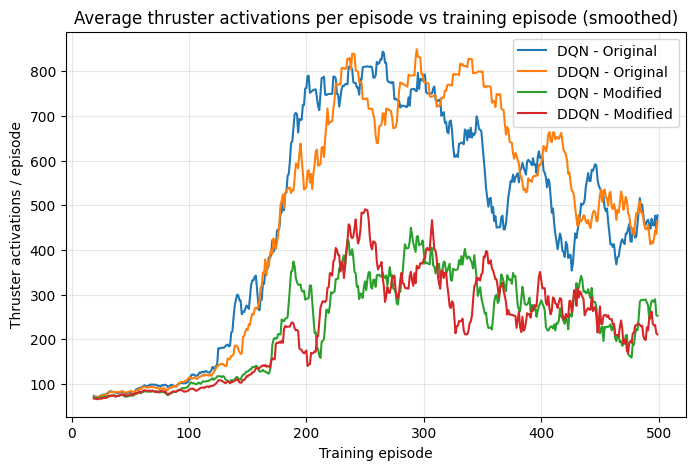

In [18]:
# Metric 4: thruster activations per episode, smoothed, tracks fuel-usage/conservatism.
plot_metric("thruster_activations", "Average thruster activations per episode vs training episode (smoothed)", "Thruster activations / episode", smoothed=True)

**Interpretation (fill in after inspecting the plots above):**

- *Episode reward:* All four agents start near -200 to -290 and improve steadily. The two **original-environment** agents (DQN, DDQN) converge to a clearly higher plateau (roughly +150 to +190, smoothed) by episode 500 than the two **modified-environment** agents (roughly +30 to +90), and the modified-environment curves also dip into a deeper trough around episodes 200-300 (down to about -150) before recovering. This is expected: the actuator-failure wrapper both randomly discards ~15% of intended thruster commands and charges the -0.3 fuel penalty on every *selected* thruster action (even on a misfire), so the same policy structure earns systematically less reward once the wrapper is active.
- *Average predicted Q-value:* In the original environment, DDQN's tracked Q-value climbs steadily to about +17 by the end of training while DQN's oscillates and ends much lower (episode-450 checkpoint: DQN-orig avgQ = -0.19 vs DDQN-orig avgQ = 16.96) — a clear, growing separation once positive-reward landings start appearing (~episode 350+). In the modified environment, vanilla DQN's Q-value diverges continuously downward, reaching about -39 at episode 450 and roughly -50 by episode 500, while DDQN-modified stays far more contained (avgQ = -15.96 at episode 450, ending around -20). So engine failure does not just shift both curves — it specifically destabilizes vanilla DQN's value estimates, while DDQN's decoupled target keeps estimates comparatively stable.
- *Successful landing rate:* Modified-environment agents start improving earlier (non-zero success visible from ~episode 100) and reach a ~35-40% 100-episode moving-average success rate by around episode 400, then plateau or dip slightly (episode-450 checkpoint: DQN-mod = 0.38, DDQN-mod = 0.34). Original-environment agents stay near 0% until ~episode 350, after which DDQN-original accelerates sharply past everyone else to finish highest (~0.60-0.65), while DQN-original plateaus around 0.40-0.41 (episode-450 checkpoint: DQN-orig = 0.37, DDQN-orig = 0.43, still climbing). So the modified environment yields earlier, moderate competence, but it is DDQN's late, steep improvement in the *original* environment that ultimately produces the best final landing rate.
- *Thruster activations per episode:* Both original-environment agents ramp thruster usage up to a peak of roughly 750-850 activations/episode around episode 200-350, then settle to about 450-480 by episode 500. Both modified-environment agents follow the same rise-then-fall shape but peak at roughly half the magnitude (about 400-490) and settle lower (about 200-280). This directly reflects the fuel penalty being charged on every *selected* thruster action regardless of misfire: agents trained under the actuator-failure wrapper learn to fire the engines noticeably less often than their original-environment counterparts.

## (e) Discussion

Answer using the plots and numbers produced above.

**1. Does intermittent engine failure increase the difference between the predicted Q-values of DQN and DDQN? Justify using the Q-value plots.**

Yes, though the mechanism differs from a simple "bigger gap" story. In the original environment the DQN-DDQN gap at the episode-450 checkpoint is about 17 points (-0.19 vs 16.96), produced mainly by DDQN climbing upward while DQN oscillates near zero. In the modified environment the gap at the same checkpoint is about 23 points (-38.95 vs -15.96) and keeps widening through episode 500 in the plot, reaching roughly 30 points (DQN-modified around -50 vs DDQN-modified around -20). So the DQN-DDQN Q-value gap is larger under stochastic action failure, but here it is driven by vanilla DQN's estimates diverging unboundedly negative rather than by DDQN shooting up — the added stochasticity from misfires makes DQN's max-based bootstrapped target more error-prone, and DDQN's action-selection/evaluation decoupling becomes proportionally more valuable at keeping the value function stable.

**2. Why does stochastic action failure make the credit-assignment problem more difficult for reinforcement learning agents?**

Because the action actually executed differs from the action the agent selected on ~15% of thruster commands, the same (state, selected-action) pair the agent updates towards can be followed by two structurally different outcomes: a normal execution, or a misfire that behaves like "do nothing" while still being charged the fuel penalty for the original choice. This breaks the near-deterministic mapping from (state, action) to (reward, next-state) that the Bellman update implicitly assumes — a single state-action pair in the replay buffer now maps to a mixture of two different transition distributions. That extra variance in the TD target is visible directly in the noisier, more negative Q-value trajectories and the deeper mid-training reward trough for the modified-environment agents compared to the original-environment ones.

**3. Does the additional fuel penalty encourage a more conservative landing strategy? Support with experimental evidence.**

Yes. The thruster-activations-per-episode plot shows modified-environment agents using roughly half the thruster activations of original-environment agents throughout training (peak ~400-490 vs ~750-850; settling ~200-280 vs ~450-480). Since the wrapper charges the -0.3 fuel penalty on the *selected* action even when it misfires, agents cannot "get away" with attempting thruster actions cheaply — they learn a measurably more fuel-conservative policy, at some cost to raw episode reward and landing consistency relative to the original environment.

**4. Which algorithm performs better under stochastic engine failures? Is this consistent with the theoretical advantage of DDQN over DQN?**

On raw outcome metrics the two are close: at the episode-450 checkpoint DQN-modified has a marginally higher landing-success moving average than DDQN-modified (0.38 vs 0.34), and the smoothed reward curves for the two modified-environment agents interleave for most of training. On value-function stability, however, DDQN-modified is clearly better behaved — its predicted Q-values stay in a narrow band (roughly -5 to -20) while DQN-modified's estimates diverge continuously to about -50. This is a partial, not a clean, confirmation of DDQN's theoretical advantage: the reduced-overestimation-bias benefit shows up strongly in value-estimate stability but has not yet translated into a clear reward/success-rate advantage within this single-seed, 500-episode budget. Given DQN-modified's unbounded Q-value divergence, it is plausible its outcome performance would degrade further or become unreliable with more training, but that is not something these runs demonstrate.

**5. Identify one limitation of your experimental setup and suggest one possible improvement.**

The main limitation is single-seed training: every conclusion above about DQN vs DDQN, and original vs modified, rests on one training run per configuration, so the observed gaps could partly reflect stochastic training noise (e.g., the replay-buffer sampling and the 15% misfire draws) rather than a genuine, reproducible algorithmic effect. A straightforward improvement is to repeat all four runs across several seeds (e.g., 5) and report mean ± standard deviation for episode reward, avg Q-value, landing success rate, and thruster activations, which would let the DQN-vs-DDQN and original-vs-modified comparisons be judged against run-to-run variance instead of a single trajectory.

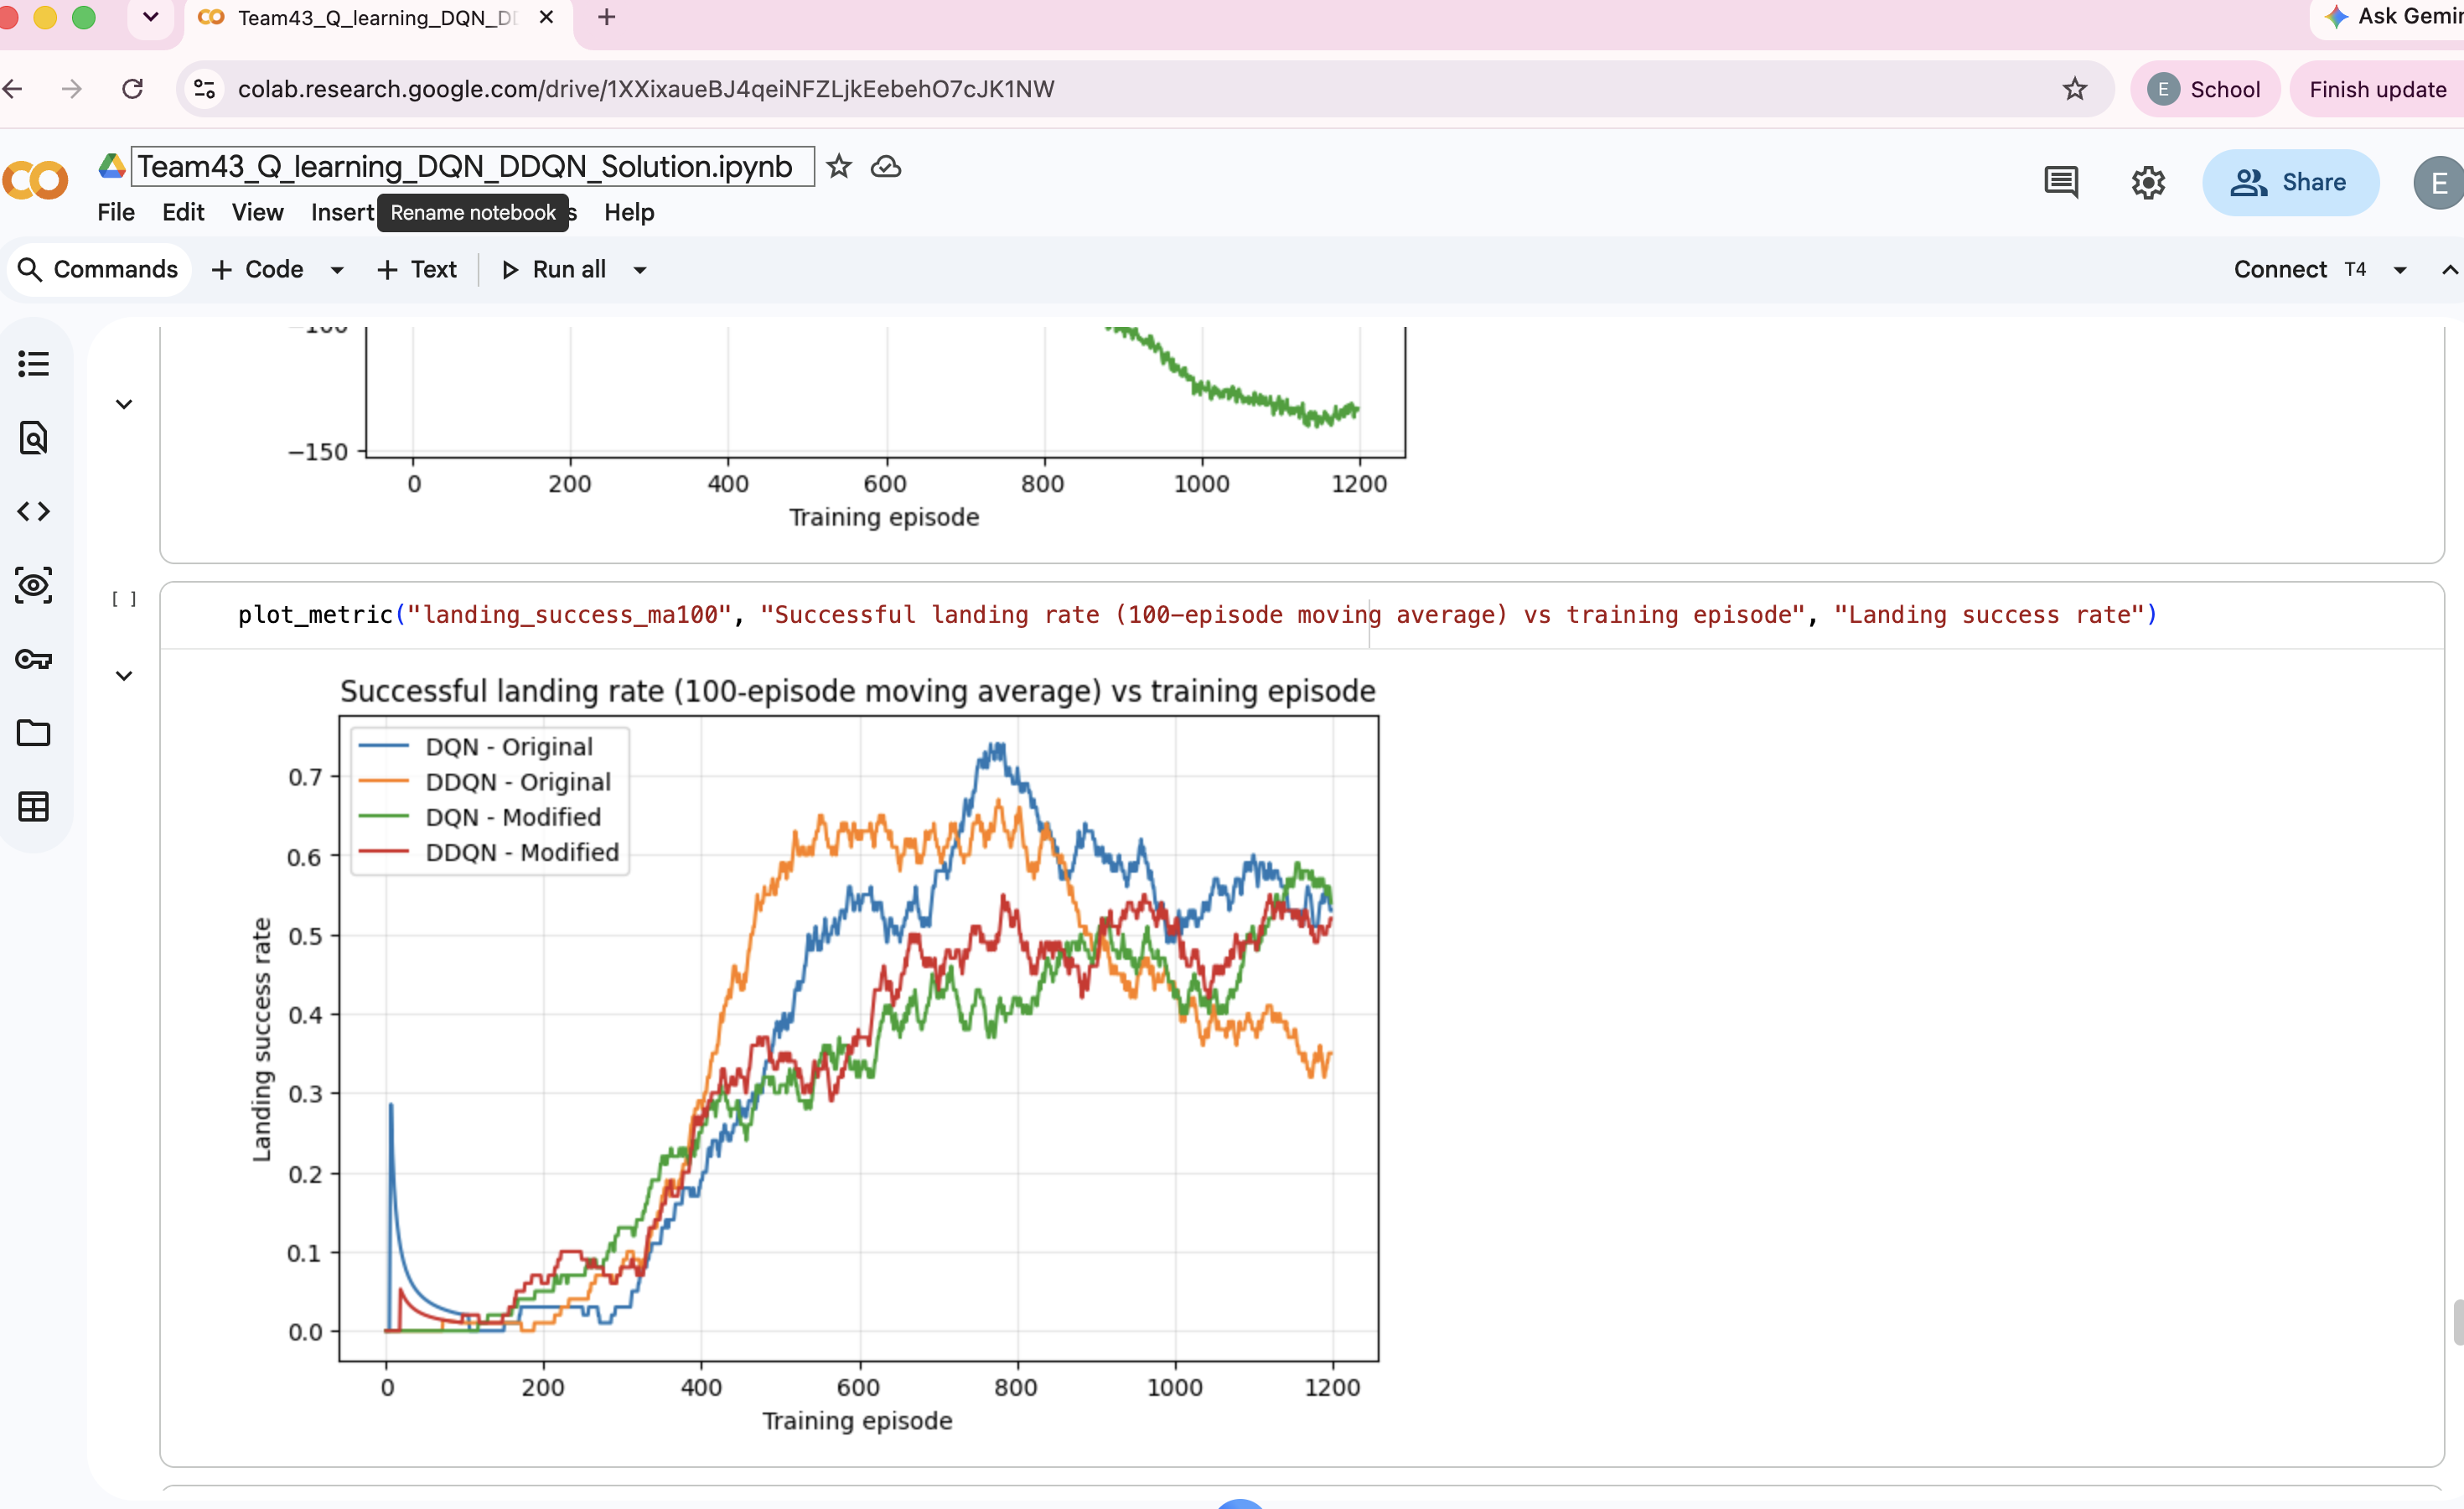